# Deep Globe Road Extraction

Semantic segmentation of roads in satellite imagery, using the [Deep Globe 2018 Road Extraction dataset](http://deepglobe.org/challenge.html) in the **DatasetNinja** export format.

## Pipeline overview

1. **Dataset exploration** — load satellite images and their JSON road annotations, and visualize them.
2. **Patch-wise dataset** — split each 1024x1024 image into overlapping 512x512 patches, build train/val/test dataloaders with augmentation.
3. **Model** — a LinkNet segmentation network with an EfficientNet-B2 encoder (pretrained on ImageNet).
4. **Training** — combined BCE + Dice + Connectivity loss, mixed-precision (AMP), cosine warm-restart schedule, checkpointing, and early stopping.

## Status

This notebook contains the complete, runnable pipeline. **Training has not been completed yet** — the training cell is included but has not been run to a final result. See the project README for setup instructions and details.


## 1. Dataset exploration and visualization

The dataset is provided in the **DatasetNinja** export format. Each satellite image (`*_sat.jpg`) has a matching JSON annotation file (`*_sat.jpg.json`) that encodes the road pixels in one of two ways:

- a compressed **bitmap mask** (base64 + zlib), or
- a **polygon** described by a list of points.

This cell:

- Picks 3 random satellite images and finds their matching annotation files.
- Converts each annotation into a binary road mask using `decode_bitmap` and `ann_to_mask`.
- Plots the satellite image, the road mask, and an overlay of the two, side by side.

The output confirms that image and annotation files are correctly matched, and shows the range of road density in the dataset — from a rural scene with under 1% road pixels to a dense highway interchange with about 29% road pixels.

=== Annotation matching check ===
img: 853055_sat.jpg  →  ann: 853055_sat.jpg.json
img: 232879_sat.jpg  →  ann: 232879_sat.jpg.json
img: 131094_sat.jpg  →  ann: 131094_sat.jpg.json



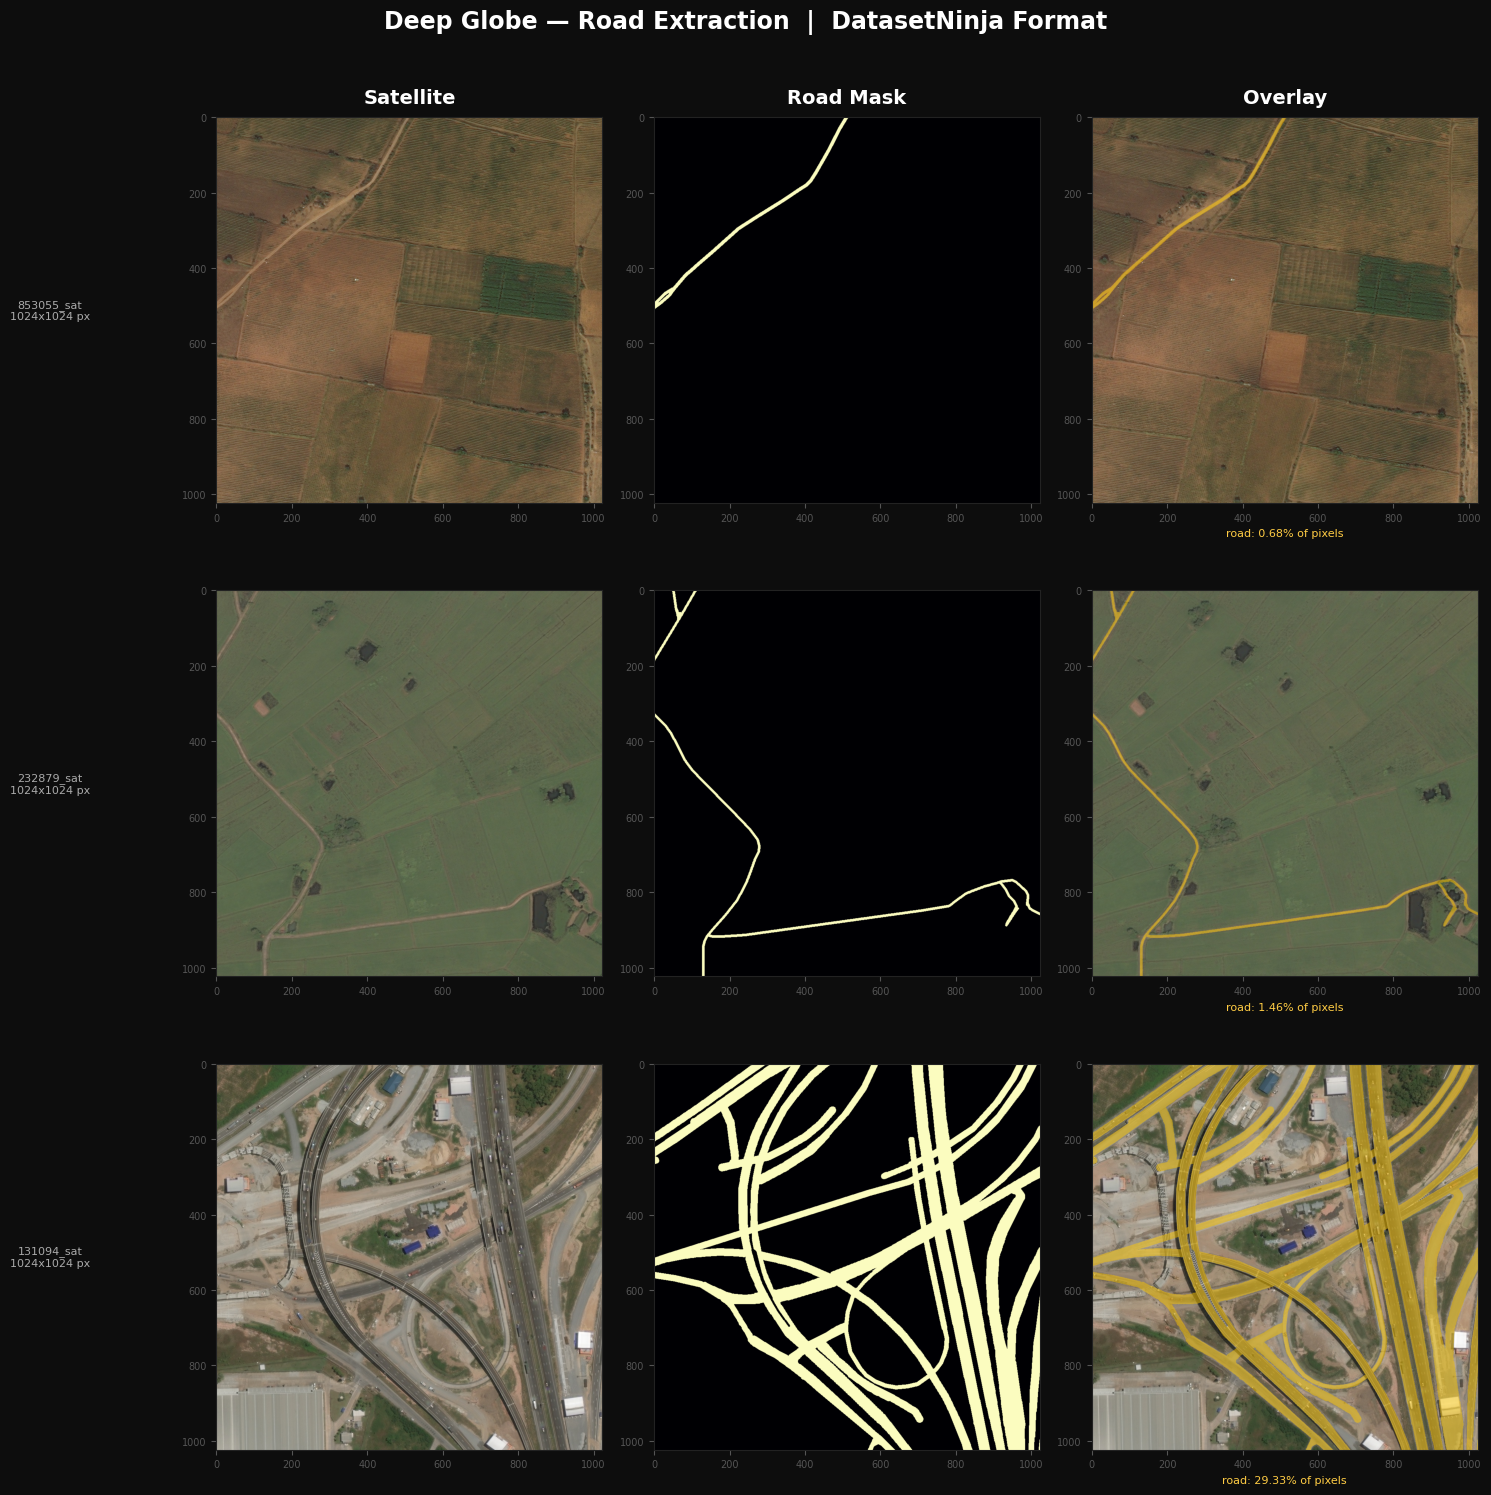

Saved → deepglobe_preview.png


In [1]:
import os
import json
import zlib
import io
import base64
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pathlib import Path
import random

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATASET_PATH = "deepglobe-2018-road-extraction-DatasetNinja/train"
IMG_DIR      = Path(DATASET_PATH) / "img"
ANN_DIR      = Path(DATASET_PATH) / "ann"
N_SAMPLES    = 3
SEED         = 42
# ─────────────────────────────────────────────────────────────────────────────

def find_ann_path(img_path, ann_dir):
    # DatasetNinja names: <filename>.json  e.g. 853055_sat.jpg.json
    candidate = ann_dir / (img_path.name + ".json")
    if candidate.exists():
        return candidate
    return None


def decode_bitmap(bitmap_obj, img_h, img_w):
    data   = bitmap_obj["data"]
    origin = bitmap_obj.get("origin", [0, 0])  # [col, row]

    raw   = zlib.decompress(base64.b64decode(data))
    patch = np.array(Image.open(io.BytesIO(raw)).convert("L"))

    if patch.max() <= 1:
        patch = (patch * 255).astype(np.uint8)

    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    r0, c0 = origin[1], origin[0]
    bh, bw = patch.shape
    r1 = min(r0 + bh, img_h)
    c1 = min(c0 + bw, img_w)
    mask[r0:r1, c0:c1] = np.maximum(mask[r0:r1, c0:c1], patch[:r1-r0, :c1-c0])
    return mask


def ann_to_mask(ann_path, img_h, img_w):
    with open(ann_path) as f:
        ann = json.load(f)

    full_mask = np.zeros((img_h, img_w), dtype=np.uint8)

    for obj in ann.get("objects", []):
        if obj.get("classTitle", "").lower() != "road":
            continue
        gtype = obj.get("geometryType", "")

        if gtype == "bitmap" and "bitmap" in obj:
            patch = decode_bitmap(obj["bitmap"], img_h, img_w)
            full_mask = np.maximum(full_mask, patch)

        elif gtype == "polygon":
            pts  = obj["points"]["exterior"]
            flat = [coord for pt in pts for coord in pt]
            if len(flat) >= 4:
                tmp = Image.new("L", (img_w, img_h), 0)
                ImageDraw.Draw(tmp).polygon(flat, fill=255)
                full_mask = np.maximum(full_mask, np.array(tmp))

    return full_mask


def overlay(img_np, mask_np, alpha=0.5):
    out = img_np.copy().astype(np.float32)
    px  = mask_np > 0
    out[px, 0] = out[px, 0] * (1 - alpha) + 255 * alpha
    out[px, 1] = out[px, 1] * (1 - alpha) + 200 * alpha
    out[px, 2] = out[px, 2] * (1 - alpha) + 0
    return out.clip(0, 255).astype(np.uint8)


# ── SAMPLE ───────────────────────────────────────────────────────────────────
random.seed(SEED)
all_imgs = sorted(IMG_DIR.glob("*.jpg")) + sorted(IMG_DIR.glob("*.png"))
samples  = random.sample(all_imgs, min(N_SAMPLES, len(all_imgs)))

# ── DEBUG: print name matching for first sample ───────────────────────────────
print("=== Annotation matching check ===")
for img_path in samples[:3]:
    ann_path = find_ann_path(img_path, ANN_DIR)
    print(f"img: {img_path.name}  →  ann: {ann_path.name if ann_path else 'NOT FOUND'}")
print()

# ── PLOT ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(15, N_SAMPLES * 5))
fig.patch.set_facecolor("#0d0d0d")

for ax, title in zip(axes[0], ["Satellite", "Road Mask", "Overlay"]):
    ax.set_title(title, fontsize=14, color="white", fontweight="bold", pad=10)

for row, img_path in enumerate(samples):
    ann_path = find_ann_path(img_path, ANN_DIR)
    img_np   = np.array(Image.open(img_path).convert("RGB"))
    h, w     = img_np.shape[:2]

    if ann_path:
        mask_np = ann_to_mask(ann_path, h, w)
    else:
        print(f"WARNING: no annotation found for {img_path.name}")
        mask_np = np.zeros((h, w), dtype=np.uint8)

    ov       = overlay(img_np, mask_np)
    road_pct = 100 * (mask_np > 0).mean()

    for col, (data, cmap) in enumerate([
        (img_np,  None),
        (mask_np, "magma"),
        (ov,      None),
    ]):
        ax = axes[row, col]
        ax.imshow(data, cmap=cmap)
        ax.set_facecolor("#0d0d0d")
        ax.tick_params(colors="#555", labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor("#222")

        if col == 0:
            ax.set_ylabel(
                f"{img_path.stem[:20]}\n{w}x{h} px",
                fontsize=8, color="#aaa", rotation=0,
                labelpad=95, va="center"
            )
        if col == 2:
            ax.set_xlabel(f"road: {road_pct:.2f}% of pixels",
                          fontsize=8, color="#ffcc44")

plt.suptitle("Deep Globe — Road Extraction  |  DatasetNinja Format",
             fontsize=17, color="white", fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig("deepglobe_preview.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → deepglobe_preview.png")

## 2. Patch-wise dataset and dataloaders

Training directly on 1024x1024 images requires a large amount of GPU memory. To work around this, the dataset is split into **512x512 patches with 25% overlap** (128 px overlap, 384 px stride).

Key design choices:

- **`PatchWiseDataset`** stores only the patch coordinates `(image_index, y, x)`. The actual image and mask are loaded and cropped only inside `__getitem__`, which keeps memory usage low even for thousands of patches.
- **Training set only:** patches with less than `MIN_ROAD_PERCENT` (0.5%) road pixels are filtered out. This removes a large number of "empty" patches that contain no road and would otherwise dominate the training data.
- **Validation and test sets** keep all patches, without filtering, so that evaluation reflects the true distribution of the data.
- **Augmentation** (`get_train_transforms`) includes horizontal/vertical flips, 90-degree rotation, `ShiftScaleRotate`, `ElasticTransform` / `GridDistortion` (for road curvature), brightness/contrast/hue/saturation jitter, Gaussian noise, and `CoarseDropout`. These target the main sources of variation in satellite road imagery: orientation, scale, curvature, lighting, and partial occlusion.

The output below reports the number of patches per split, a sanity check on batch shapes and memory, and a visualization of 8 training patches with their image, mask, and overlay.

C:\Users\LENOVO\AppData\Roaming\Python\Python310\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8152\2393099759.py:202: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8152\2393099759.py:203: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


DEEP GLOBE — PATCH-WISE (MEMORY EFFICIENT)
   Image: 1024×1024  Patch: 512×512
   Overlap: 128px (25%)
   Stride: 384px  Batch: 8
   Min road % (train): 0.5%

   Total annotated images: 6,226

Creating Patch-Wise Datasets (on-the-fly extraction)...

TRAINING SET:
   Patch config: 512×512, overlap=128px (25%), stride=384px
   Indexing patches (no pre-loading)...


   Indexing: 100%|████████████████████████████████████████████████████████████████| 4980/4980 [00:28<00:00, 177.61it/s]


   Total patches: 34,780 (7.0 per image)

VALIDATION SET:
   Patch config: 512×512, overlap=128px (25%), stride=384px
   Indexing patches (no pre-loading)...


   Indexing: 100%|████████████████████████████████████████████████████████████████| 622/622 [00:00<00:00, 10275.58it/s]


   Total patches: 5,598 (9.0 per image)

TEST SET:
   Patch config: 512×512, overlap=128px (25%), stride=384px
   Indexing patches (no pre-loading)...


   Indexing: 100%|████████████████████████████████████████████████████████████████| 624/624 [00:00<00:00, 10252.41it/s]

   Total patches: 5,616 (9.0 per image)

Creating DataLoaders...

SANITY CHECK

   Full images  : 6,226
   Total patches: 45,994 (7.4x)
   Train : 34,780 patches, 4,347 batches
   Val   : 5,598 patches, 700 batches
   Test  : 5,616 patches, 702 batches

Batch Inspection...


   Train: img=torch.Size([8, 3, 512, 512]), mask=torch.Size([8, 1, 512, 512]), road=5.15%, mem=32.0 MB
   Val: img=torch.Size([8, 3, 512, 512]), mask=torch.Size([8, 1, 512, 512]), road=8.06%, mem=32.0 MB
   Test: img=torch.Size([8, 3, 512, 512]), mask=torch.Size([8, 1, 512, 512]), road=9.89%, mem=32.0 MB


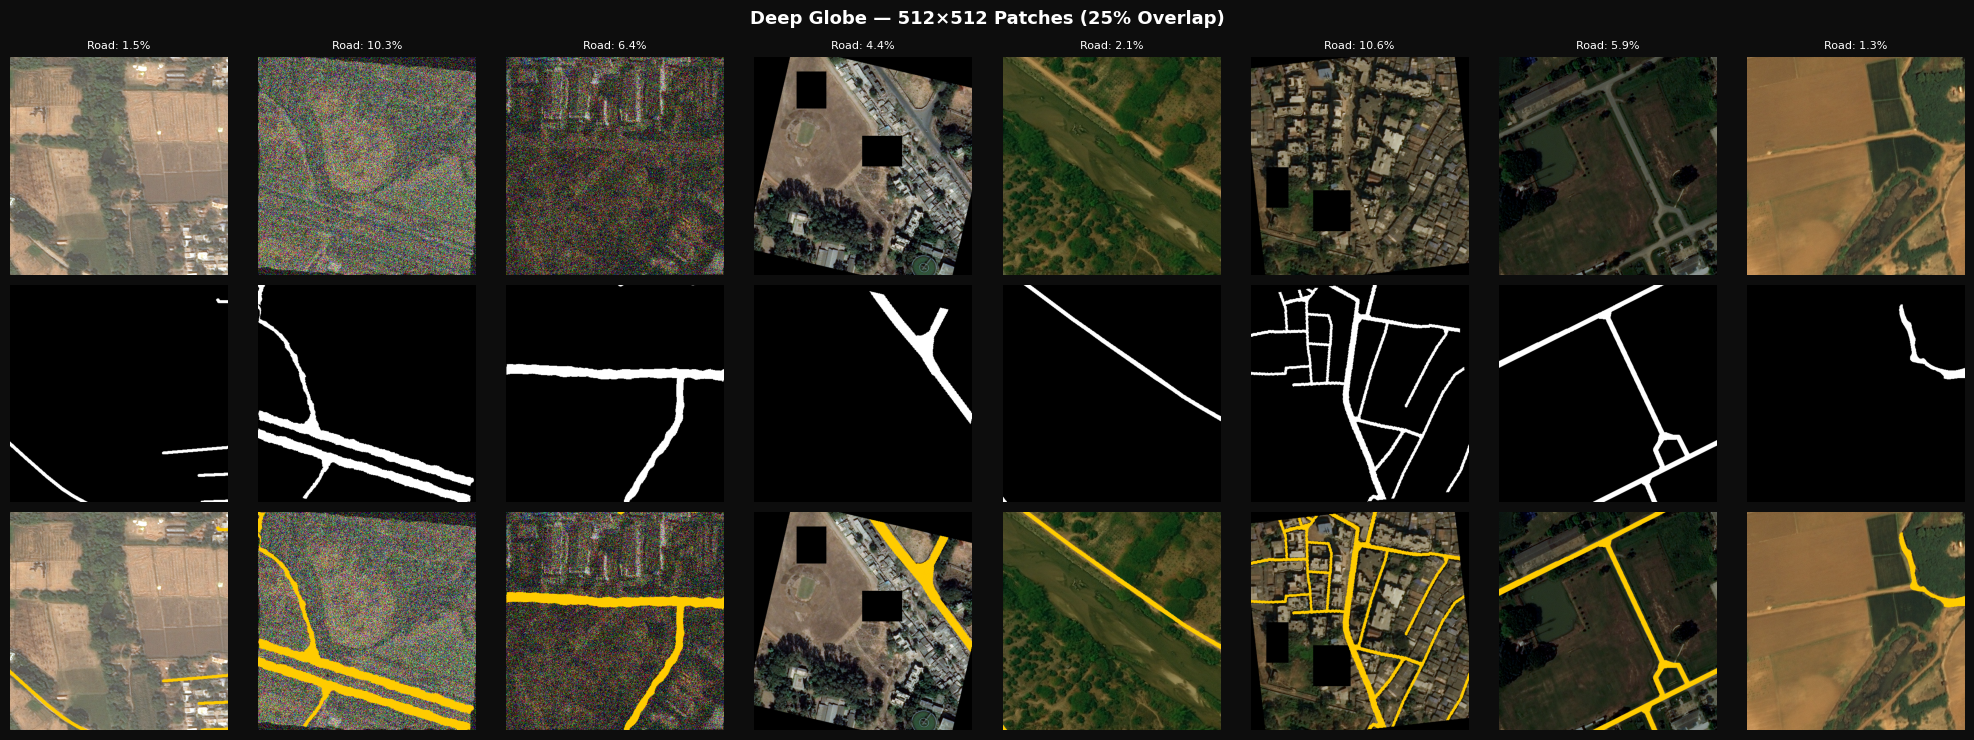


READY FOR TRAINING!
   Total patches: 45,994
   Train: 34,780 | Val: 5,598 | Test: 5,616
   Patch: 512×512 | Overlap: 128px | Batch: 8


In [2]:
import os
import json
import zlib
import io
import base64
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("deepglobe-2018-road-extraction-DatasetNinja")
TRAIN_IMG_DIR = DATASET_ROOT / "train" / "img"
TRAIN_ANN_DIR = DATASET_ROOT / "train" / "ann"

IMG_SIZE    = 1024
PATCH_SIZE  = 512
PATCH_OVERLAP = 128   # 25% overlap
STRIDE      = PATCH_SIZE - PATCH_OVERLAP  # 384

BATCH_SIZE  = 8       # Reduced: EfficientNet-B2/B3 needs more VRAM than MobileNetV2
SEED        = 42

TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

MIN_ROAD_PERCENT = 0.5
# ─────────────────────────────────────────────────────────────────────────────


class DeepGlobeRoadDataset(Dataset):
    """Full image dataset (for non-patch training)."""

    def __init__(self, img_paths, ann_paths, transform=None):
        self.img_paths = img_paths
        self.ann_paths = ann_paths
        self.transform = transform

    @staticmethod
    def decode_bitmap(bitmap_obj, img_h, img_w):
        data   = bitmap_obj["data"]
        origin = bitmap_obj.get("origin", [0, 0])
        raw    = zlib.decompress(base64.b64decode(data))
        patch  = np.array(Image.open(io.BytesIO(raw)).convert("L"))
        if patch.max() <= 1:
            patch = (patch * 255).astype(np.uint8)
        mask = np.zeros((img_h, img_w), dtype=np.uint8)
        r0, c0 = origin[1], origin[0]
        bh, bw = patch.shape
        r1 = min(r0 + bh, img_h)
        c1 = min(c0 + bw, img_w)
        mask[r0:r1, c0:c1] = np.maximum(mask[r0:r1, c0:c1], patch[:r1-r0, :c1-c0])
        return mask

    @staticmethod
    def ann_to_mask(ann_path, img_h, img_w):
        with open(ann_path) as f:
            ann = json.load(f)
        full_mask = np.zeros((img_h, img_w), dtype=np.uint8)
        for obj in ann.get("objects", []):
            if obj.get("classTitle", "").lower() != "road":
                continue
            geometry_type = obj.get("geometryType", "")
            if geometry_type == "bitmap" and "bitmap" in obj:
                patch = DeepGlobeRoadDataset.decode_bitmap(obj["bitmap"], img_h, img_w)
                full_mask = np.maximum(full_mask, patch)
            elif geometry_type == "polygon":
                pts  = obj["points"]["exterior"]
                flat = [coord for pt in pts for coord in pt]
                if len(flat) >= 4:
                    tmp = Image.new("L", (img_w, img_h), 0)
                    ImageDraw.Draw(tmp).polygon(flat, fill=255)
                    full_mask = np.maximum(full_mask, np.array(tmp))
        return full_mask

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.img_paths[idx]).convert("RGB"))
        mask  = self.ann_to_mask(self.ann_paths[idx], image.shape[0], image.shape[1])
        mask  = (mask > 127).astype(np.float32)
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"].unsqueeze(0)
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask  = torch.from_numpy(mask).unsqueeze(0)
        return {"image": image, "mask": mask, "path": str(self.img_paths[idx])}


class PatchWiseDataset(Dataset):
    """Extract patches ON-THE-FLY without storing in memory."""

    def __init__(self, img_paths, ann_paths, patch_size=512, overlap=128,
                 transform=None, min_road_percent=0.0, is_training=True):
        self.img_paths        = img_paths
        self.ann_paths        = ann_paths
        self.patch_size       = patch_size
        self.overlap          = overlap
        self.stride           = patch_size - overlap
        self.transform        = transform
        self.min_road_percent = min_road_percent
        self.is_training      = is_training
        self.patch_index      = []

        print(f"   Patch config: {patch_size}×{patch_size}, overlap={overlap}px "
              f"({100*overlap/patch_size:.0f}%), stride={self.stride}px")
        print(f"   Indexing patches (no pre-loading)...")

        for img_idx in tqdm(range(len(img_paths)), desc="   Indexing"):
            with Image.open(img_paths[img_idx]) as img:
                h, w = img.size[1], img.size[0]

            y_positions = list(range(0, h - patch_size + 1, self.stride))
            x_positions = list(range(0, w - patch_size + 1, self.stride))
            if y_positions[-1] + patch_size < h:
                y_positions.append(h - patch_size)
            if x_positions[-1] + patch_size < w:
                x_positions.append(w - patch_size)

            if is_training and min_road_percent > 0:
                mask = DeepGlobeRoadDataset.ann_to_mask(ann_paths[img_idx], h, w)
                mask = (mask > 127).astype(np.uint8)
                for y in y_positions:
                    for x in x_positions:
                        if 100 * mask[y:y+patch_size, x:x+patch_size].mean() >= min_road_percent:
                            self.patch_index.append((img_idx, y, x))
            else:
                for y in y_positions:
                    for x in x_positions:
                        self.patch_index.append((img_idx, y, x))

        patches_per_img = len(self.patch_index) / max(len(img_paths), 1)
        print(f"   Total patches: {len(self.patch_index):,} ({patches_per_img:.1f} per image)")

    def __len__(self):
        return len(self.patch_index)

    def __getitem__(self, idx):
        img_idx, y, x = self.patch_index[idx]
        image = np.array(Image.open(self.img_paths[img_idx]).convert("RGB"))
        mask  = DeepGlobeRoadDataset.ann_to_mask(self.ann_paths[img_idx], image.shape[0], image.shape[1])
        mask  = (mask > 127).astype(np.uint8)

        img_patch  = image[y:y+self.patch_size, x:x+self.patch_size].copy()
        mask_patch = mask[y:y+self.patch_size,  x:x+self.patch_size].copy().astype(np.float32)
        road_percent = 100 * mask_patch.mean()
        del image, mask

        if self.transform:
            aug        = self.transform(image=img_patch, mask=mask_patch)
            img_patch  = aug["image"]
            mask_patch = aug["mask"].unsqueeze(0)
        else:
            img_patch  = torch.from_numpy(img_patch).permute(2, 0, 1).float() / 255.0
            mask_patch = torch.from_numpy(mask_patch).unsqueeze(0)

        return {
            "image":        img_patch,
            "mask":         mask_patch,
            "path":         str(self.img_paths[img_idx]),
            "position":     (y, x),
            "road_percent": road_percent,
        }


# ── TRANSFORMS ──────────────────────────────────────────────────────────────
def get_train_transforms():
    """
    Stronger augmentations vs original:
    - Added ShiftScaleRotate  : handles road orientation variation
    - Added ElasticTransform  : simulates road curvature variation
    - Added GridDistortion    : improves generalization on curved roads
    - Added CoarseDropout     : forces model to predict from partial context
      (replaces deprecated Cutout)
    - Added GaussNoise         : improves robustness to sensor noise
    - Kept HFlip / VFlip / Rotate90 / BrightnessContrast
    """
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.1, rotate_limit=15,
            border_mode=0, p=0.5
        ),
        A.OneOf([
            A.ElasticTransform(alpha=120, sigma=6, p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
        ], p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.GaussNoise(var_limit=(10, 50), p=0.3),
        A.CoarseDropout(
            max_holes=8, max_height=32, max_width=32,
            min_holes=1, fill_value=0, mask_fill_value=0, p=0.3
        ),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_val_test_transforms():
    return A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


# ── MAIN ────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    print("=" * 70)
    print("DEEP GLOBE — PATCH-WISE (MEMORY EFFICIENT)")
    print("=" * 70)
    print(f"   Image: {IMG_SIZE}×{IMG_SIZE}  Patch: {PATCH_SIZE}×{PATCH_SIZE}")
    print(f"   Overlap: {PATCH_OVERLAP}px ({100*PATCH_OVERLAP/PATCH_SIZE:.0f}%)")
    print(f"   Stride: {STRIDE}px  Batch: {BATCH_SIZE}")
    print(f"   Min road % (train): {MIN_ROAD_PERCENT}%")
    print("=" * 70)

    all_imgs = sorted(list(TRAIN_IMG_DIR.glob("*.jpg")))
    all_anns = [TRAIN_ANN_DIR / (img.name + ".json") for img in all_imgs]
    print(f"\n   Total annotated images: {len(all_imgs):,}")

    total      = len(all_imgs)
    train_size = int(TRAIN_RATIO * total)
    val_size   = int(VAL_RATIO   * total)

    indices    = list(range(total))
    random.shuffle(indices)

    train_img = [all_imgs[i] for i in indices[:train_size]]
    train_ann = [all_anns[i] for i in indices[:train_size]]
    val_img   = [all_imgs[i] for i in indices[train_size:train_size+val_size]]
    val_ann   = [all_anns[i] for i in indices[train_size:train_size+val_size]]
    test_img  = [all_imgs[i] for i in indices[train_size+val_size:]]
    test_ann  = [all_anns[i] for i in indices[train_size+val_size:]]

    print("\nCreating Patch-Wise Datasets (on-the-fly extraction)...")
    print("=" * 70)

    print("\nTRAINING SET:")
    train_dataset = PatchWiseDataset(
        train_img, train_ann, patch_size=PATCH_SIZE, overlap=PATCH_OVERLAP,
        transform=get_train_transforms(), min_road_percent=MIN_ROAD_PERCENT, is_training=True
    )
    print("\nVALIDATION SET:")
    val_dataset = PatchWiseDataset(
        val_img, val_ann, patch_size=PATCH_SIZE, overlap=PATCH_OVERLAP,
        transform=get_val_test_transforms(), min_road_percent=0.0, is_training=False
    )
    print("\nTEST SET:")
    test_dataset = PatchWiseDataset(
        test_img, test_ann, patch_size=PATCH_SIZE, overlap=PATCH_OVERLAP,
        transform=get_val_test_transforms(), min_road_percent=0.0, is_training=False
    )

    # ── DATALOADERS ─────────────────────────────────────────────────────────
    # pin_memory=False  →  required on Windows (avoids multiprocessing errors)
    # num_workers=0     →  required on Windows
    print("\nCreating DataLoaders...")
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=True, drop_last=False
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=True, drop_last=False
    )

    # ── SANITY CHECK ────────────────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("SANITY CHECK")
    print("=" * 70)

    total_patches = len(train_dataset) + len(val_dataset) + len(test_dataset)
    print(f"\n   Full images  : {len(all_imgs):,}")
    print(f"   Total patches: {total_patches:,} ({total_patches/len(all_imgs):.1f}x)")
    print(f"   Train : {len(train_dataset):,} patches, {len(train_loader):,} batches")
    print(f"   Val   : {len(val_dataset):,} patches, {len(val_loader):,} batches")
    print(f"   Test  : {len(test_dataset):,} patches, {len(test_loader):,} batches")

    print("\nBatch Inspection...")
    train_batch = next(iter(train_loader))
    val_batch   = next(iter(val_loader))
    test_batch  = next(iter(test_loader))

    for name, batch in [("Train", train_batch), ("Val", val_batch), ("Test", test_batch)]:
        road_pct  = 100 * batch['mask'].mean().item()
        batch_mem = (batch['image'].element_size() * batch['image'].nelement() +
                     batch['mask'].element_size()  * batch['mask'].nelement()) / 1024**2
        print(f"   {name}: img={batch['image'].shape}, mask={batch['mask'].shape}, "
              f"road={road_pct:.2f}%, mem={batch_mem:.1f} MB")

    # ── VISUALIZE ───────────────────────────────────────────────────────────
    def denormalize(img):
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img  = img.permute(1, 2, 0).cpu().numpy()
        return (img * std + mean).clip(0, 1)

    n_vis = 8
    fig, axes = plt.subplots(3, n_vis, figsize=(n_vis*2.5, 7.5))
    fig.patch.set_facecolor("#0d0d0d")

    for i in range(n_vis):
        img     = denormalize(train_batch['image'][i])
        mask    = train_batch['mask'][i, 0].cpu().numpy()
        overlay = img.copy()
        overlay[mask > 0.5] = [1.0, 0.8, 0.0]
        road_pct = train_batch['road_percent'][i].item()

        axes[0, i].imshow(img)
        axes[1, i].imshow(mask, cmap='gray')
        axes[2, i].imshow(overlay)
        axes[0, i].set_title(f"Road: {road_pct:.1f}%", fontsize=8, color='white')
        for j in range(3):
            axes[j, i].axis('off')

    axes[0, 0].set_ylabel("Image",   fontsize=11, color='white', fontweight='bold')
    axes[1, 0].set_ylabel("Mask",    fontsize=11, color='white', fontweight='bold')
    axes[2, 0].set_ylabel("Overlay", fontsize=11, color='white', fontweight='bold')

    plt.suptitle(
        f"Deep Globe — {PATCH_SIZE}×{PATCH_SIZE} Patches "
        f"({100*PATCH_OVERLAP/PATCH_SIZE:.0f}% Overlap)",
        fontsize=13, color='white', fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig("patchwise_25overlap_memory_efficient.png",
                dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    print("\nREADY FOR TRAINING!")
    print(f"   Total patches: {total_patches:,}")
    print(f"   Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
    print(f"   Patch: {PATCH_SIZE}×{PATCH_SIZE} | Overlap: {PATCH_OVERLAP}px | Batch: {BATCH_SIZE}")
    print("=" * 70)

## 3. Model: LinkNet with EfficientNet-B2 encoder

The segmentation model is a **LinkNet** architecture (from `segmentation_models_pytorch`) combined with an **EfficientNet-B2** encoder pretrained on ImageNet.

- **Encoder (EfficientNet-B2):** uses compound scaling (width, depth, and input resolution scaled together) and MBConv blocks with Squeeze-and-Excitation attention. This gives a stronger feature extractor than a plain MobileNetV2 while still being light enough for a 6 GB GPU.
- **Decoder (LinkNet):** each decoder stage is a 1x1 convolution, a transposed convolution, and another 1x1 convolution, with skip connections added (not concatenated) to the encoder features. This keeps the decoder lightweight compared to a U-Net decoder.
- **Input / output:** input is `(B, 3, 512, 512)`, output is `(B, 1, 512, 512)` logits (apply sigmoid to get a probability map).

The cell also prints a comparison of model sizes for alternative encoders (MobileNetV2, EfficientNet-B0/B2/B3, ResNet34/ResNet18) and a full layer-by-layer summary using `torchinfo`.

In [3]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from torchinfo import summary

# ── MODEL ─────────────────────────────────────────────────────────────────────
class LinkNetRoadExtraction(nn.Module):
    """
    LinkNet for road extraction.

    Encoder options ranked by VRAM / quality trade-off:
    ─────────────────────────────────────────────────────────────────────────────
    Encoder               Params   VRAM@BS8   Expected IoU   Notes
    ─────────────────────────────────────────────────────────────────────────────
    mobilenet_v2          4.3M     ~3.5 GB    ~0.58          Original (too weak)
    efficientnet-b0       6.5M     ~4.0 GB    ~0.62          Good baseline
    efficientnet-b2       9.2M     ~4.8 GB    ~0.65          ★ Recommended (RTX 3060)
    efficientnet-b3      12.3M     ~6.0 GB    ~0.67          Max for 6GB VRAM
    resnet34             24.4M     ~7.0 GB    ~0.66          Too heavy for RTX 3060
    ─────────────────────────────────────────────────────────────────────────────

    Why EfficientNet-B2 over MobileNetV2?
    - ~2× more parameters than MobileNetV2, but still fits in 6GB VRAM at BS=8
    - Compound scaling (width + depth + resolution together) vs MobileNetV2's
      simple width scaling → better feature extraction per parameter
    - ImageNet accuracy: EfficientNet-B2=80.1% vs MobileNetV2=72.0%
    - Expected IoU gain on Deep Globe: +0.06 to +0.08 over MobileNetV2

    Why not EfficientNet-B4 or ResNet50?
    - B4 needs ~8GB VRAM at BS=8 → OOM on RTX 3060
    - ResNet50 is 25M params → also OOM risk
    - For university cluster training: you can switch to B4 or ResNet50
    """

    def __init__(self, encoder_name="efficientnet-b2", pretrained=True):
        super().__init__()
        self.model = smp.Linknet(
            encoder_name=encoder_name,
            encoder_weights='imagenet' if pretrained else None,
            in_channels=3,
            classes=1,
        )
        self.encoder_name = encoder_name

    def forward(self, x):
        return self.model(x)

    def get_model_size(self):
        return sum(p.numel() for p in self.parameters()) / 1e6


# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────
if __name__ == '__main__':
    print("=" * 60)
    print("LINKNET + EFFICIENTNET-B2 — ROAD EXTRACTION")
    print("=" * 60)

    model = LinkNetRoadExtraction(encoder_name="efficientnet-b2", pretrained=True)

    print(f"\nModel Statistics:")
    print(f"   Total Parameters : {model.get_model_size():.2f}M")
    print(f"   Trainable        : {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M")
    print(f"   Pretrained       : True (EfficientNet-B2 on ImageNet)")

    print(f"\nArchitecture:")
    print(f"   Encoder: EfficientNet-B2")
    print(f"     - Compound scaling (width + depth + resolution)")
    print(f"     - MBConv blocks with SE (Squeeze-and-Excitation) attention")
    print(f"     - Channels: 16 → 24 → 48 → 88 → 120 → 208 → 352")
    print(f"     - SE ratio: 0.25 (channel attention at every block)")
    print(f"   Decoder: LinkNet Decoder")
    print(f"     - Each block: Conv(1×1) + ConvTranspose + Conv(1×1)")
    print(f"     - Skip connections via addition (not concatenation)")
    print(f"     - Lighter decoder than U-Net")

    print(f"\nInput/Output:")
    print(f"   Input  : (B, 3, 512, 512)")
    print(f"   Output : (B, 1, 512, 512)  [logits, apply sigmoid for probability]")

    # Size comparison
    mobilenet_model = LinkNetRoadExtraction(encoder_name="mobilenet_v2",   pretrained=False)
    b0_model        = LinkNetRoadExtraction(encoder_name="efficientnet-b0", pretrained=False)
    b3_model        = LinkNetRoadExtraction(encoder_name="efficientnet-b3", pretrained=False)

    print(f"\nSize Comparison:")
    print(f"   LinkNet + MobileNetV2     : {mobilenet_model.get_model_size():.2f}M  (original, too weak)")
    print(f"   LinkNet + EfficientNet-B0 : {b0_model.get_model_size():.2f}M  (safe option)")
    print(f"   LinkNet + EfficientNet-B2 : {model.get_model_size():.2f}M  ★ recommended")
    print(f"   LinkNet + EfficientNet-B3 : {b3_model.get_model_size():.2f}M  (max for 6GB VRAM)")

    print(f"\nDetailed Layer Summary:")
    print("=" * 60)
    model_summary = summary(
        model,
        input_size=(1, 3, 512, 512),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        depth=3,
        verbose=1
    )

LINKNET + EFFICIENTNET-B2 — ROAD EXTRACTION

Model Statistics:
   Total Parameters : 7.89M
   Trainable        : 7.89M
   Pretrained       : True (EfficientNet-B2 on ImageNet)

Architecture:
   Encoder: EfficientNet-B2
     - Compound scaling (width + depth + resolution)
     - MBConv blocks with SE (Squeeze-and-Excitation) attention
     - Channels: 16 → 24 → 48 → 88 → 120 → 208 → 352
     - SE ratio: 0.25 (channel attention at every block)
   Decoder: LinkNet Decoder
     - Each block: Conv(1×1) + ConvTranspose + Conv(1×1)
     - Skip connections via addition (not concatenation)
     - Lighter decoder than U-Net

Input/Output:
   Input  : (B, 3, 512, 512)
   Output : (B, 1, 512, 512)  [logits, apply sigmoid for probability]


C:\Program Files\Python310\lib\site-packages\segmentation_models_pytorch\encoders\__init__.py:136: UserWarning: Error loading efficientnet-b2 `imagenet` weights from Hugging Face Hub, trying loading from original url...
  warnings.warn(message, UserWarning)



Size Comparison:
   LinkNet + MobileNetV2     : 4.32M  (original, too weak)
   LinkNet + EfficientNet-B0 : 4.17M  (safe option)
   LinkNet + EfficientNet-B2 : 7.89M  ★ recommended
   LinkNet + EfficientNet-B3 : 10.93M  (max for 6GB VRAM)

Detailed Layer Summary:
Layer (type:depth-idx)                                       Input Shape          Output Shape         Param #              Trainable
LinkNetRoadExtraction                                        [1, 3, 512, 512]     [1, 1, 512, 512]     --                   True
├─Linknet: 1-1                                               [1, 3, 512, 512]     [1, 1, 512, 512]     --                   True
│    └─EfficientNetEncoder: 2-1                              [1, 3, 512, 512]     [1, 3, 512, 512]     498,432              True
│    │    └─Conv2dStaticSamePadding: 3-1                     [1, 3, 512, 512]     [1, 32, 256, 256]    864                  True
│    │    └─BatchNorm2d: 3-2                                 [1, 32, 256, 256]    [1, 

## 4. Training

This cell defines the loss function, training/validation loops, checkpointing, and runs the training loop.

**Loss function (combination of three terms):**

- **BCE loss** (weight 0.3) with `pos_weight=6` to address the class imbalance between road and background pixels.
- **Dice loss** (weight 0.5) to directly optimize for the overlap (IoU-style) metric.
- **Connectivity loss** (weight 0.2), computed on a downsampled mask, to encourage continuous, unbroken road predictions instead of fragmented segments.

**Optimization:**

- `AdamW` optimizer, learning rate `1e-3`, weight decay `1e-4`.
- `CosineAnnealingWarmRestarts` schedule (restarts after 10, then 20, then 40 epochs) to help the model escape local minima over a long training run.
- Mixed-precision training (`torch.cuda.amp`) with gradient clipping for numerical stability.

**Checkpointing and early stopping:**

- The model with the best validation IoU is saved to `checkpoints/best_model.pth`.
- The latest training state is saved to `checkpoints/latest_checkpoint.pth` (for resuming with `RESUME_TRAINING=True`).
- Training stops early if the validation IoU does not improve for `PATIENCE=7` consecutive epochs.

> **Note:** Training has not been completed yet. Running this cell requires a CUDA-capable GPU and the Deep Globe dataset extracted to `deepglobe-2018-road-extraction-DatasetNinja/`. On an RTX 3060 (6 GB) with batch size 8, expect roughly 25-30 minutes per epoch.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import segmentation_models_pytorch as smp
import numpy as np
from tqdm import tqdm
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================
NUM_EPOCHS    = 30              # More epochs: EfficientNet converges slower
LEARNING_RATE = 1e-3            # Lower LR: EfficientNet is more sensitive than MobileNetV2
WEIGHT_DECAY  = 1e-4
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BCE_WEIGHT          = 0.3
DICE_WEIGHT         = 0.5
CONNECTIVITY_WEIGHT = 0.2

# pos_weight: how much more to penalize missing a road pixel vs false alarm
# Original was 15 → caused high recall (0.88) but low precision (0.63)
# Root cause: model learns "predict road everywhere" to avoid false negatives
# Fix: lower to 5–7. This balances precision and recall.
POS_WEIGHT = 6

USE_AMP = True

# Early stopping: stop if val IoU does not improve for this many epochs
PATIENCE = 7

CHECKPOINT_DIR  = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH    = CHECKPOINT_DIR / "best_model.pth"
LATEST_CHECKPOINT  = CHECKPOINT_DIR / "latest_checkpoint.pth"

RESUME_TRAINING = False

print("=" * 70)
print("ROAD EXTRACTION — LINKNET + EFFICIENTNET-B2 + AMP")
print("=" * 70)
print(f"   Device: {DEVICE} | AMP: {USE_AMP}")
print(f"   pos_weight: {POS_WEIGHT}  (was 15 → caused precision/recall imbalance)")
print(f"   Patience: {PATIENCE} epochs")
print("=" * 70)

# ============================================================================
# MODEL
# ============================================================================
model = smp.Linknet(
    encoder_name='efficientnet-b2',   # Changed from mobilenet_v2
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
).to(DEVICE)

params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nLinkNet + EfficientNet-B2 | {params:.1f}M params")

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred   = torch.sigmoid(pred.float())
        target = target.float()
        intersection = (pred * target).sum(dim=(1, 2, 3))
        union        = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return (1.0 - dice).mean()


class ConnectivityLoss(nn.Module):
    """Connectivity loss using average pooling — AMP safe."""

    def __init__(self, pool_size=4):
        super().__init__()
        self.pool = nn.AvgPool2d(kernel_size=pool_size, stride=pool_size)

    def forward(self, pred, target):
        with autocast(enabled=False):
            pred   = torch.sigmoid(pred.float())
            target = target.float()
            return F.l1_loss(self.pool(pred), self.pool(target))


class RoadExtractionLoss(nn.Module):
    """Combined: BCE + Dice + Connectivity."""

    def __init__(self, bce_weight=0.3, dice_weight=0.5, connectivity_weight=0.2, pos_weight=None):
        super().__init__()
        self.bce_weight          = bce_weight
        self.dice_weight         = dice_weight
        self.connectivity_weight = connectivity_weight
        self.pos_weight          = pos_weight
        self.dice                = DiceLoss()
        self.connectivity        = ConnectivityLoss(pool_size=4)
        self.bce_loss_value          = 0.0
        self.dice_loss_value         = 0.0
        self.connectivity_loss_value = 0.0

    def forward(self, pred, target):
        if self.pos_weight is not None:
            pw  = torch.tensor([self.pos_weight], device=pred.device, dtype=pred.dtype)
            bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pw)
        else:
            bce = F.binary_cross_entropy_with_logits(pred, target)

        dice = self.dice(pred, target)
        conn = self.connectivity(pred, target)

        self.bce_loss_value          = bce.item()
        self.dice_loss_value         = dice.item()
        self.connectivity_loss_value = conn.item()

        return self.bce_weight * bce + self.dice_weight * dice + self.connectivity_weight * conn


# ============================================================================
# METRICS
# ============================================================================
@torch.no_grad()
def compute_metrics(pred, target, threshold=0.5):
    pred        = pred.float()
    target      = target.float()
    pred_binary = (torch.sigmoid(pred) > threshold).float()

    tp = (pred_binary * target).sum()
    fp = (pred_binary * (1 - target)).sum()
    fn = ((1 - pred_binary) * target).sum()

    prec = (tp + 1e-7) / (tp + fp + 1e-7)
    rec  = (tp + 1e-7) / (tp + fn + 1e-7)

    return {
        'iou'      : ((tp + 1e-7) / (tp + fp + fn + 1e-7)).item(),
        'dice'     : ((2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)).item(),
        'precision': prec.item(),
        'recall'   : rec.item(),
        'f1'       : (2 * prec * rec / (prec + rec + 1e-7)).item(),
    }


# ============================================================================
# TRAINING
# ============================================================================
def train_epoch(model, loader, optimizer, criterion, scaler, device, epoch, use_amp=True):
    model.train()
    total_loss  = 0.0
    total_bce   = 0.0
    total_dice  = 0.0
    total_conn  = 0.0
    metrics     = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'f1': 0}

    pbar = tqdm(loader, desc=f"Epoch {epoch:3d} [Train]",
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
                colour='blue', ncols=100)

    for batch in pbar:
        images = batch['image'].to(device, non_blocking=True)
        masks  = batch['mask'].to(device,  non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss    = criterion(outputs, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        total_bce  += criterion.bce_loss_value
        total_dice += criterion.dice_loss_value
        total_conn += criterion.connectivity_loss_value

        bm = compute_metrics(outputs.detach(), masks)
        for k in metrics:
            metrics[k] += bm[k]

        pbar.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'IoU' : f"{bm['iou']:.3f}",
            'Prec': f"{bm['precision']:.3f}",
            'Rec' : f"{bm['recall']:.3f}",
        })

    n = len(loader)
    return (total_loss/n, total_bce/n, total_dice/n, total_conn/n,
            {k: v/n for k, v in metrics.items()})


def validate(model, loader, criterion, device, epoch, use_amp=True):
    model.eval()
    total_loss = 0.0
    total_bce  = 0.0
    total_dice = 0.0
    total_conn = 0.0
    metrics    = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'f1': 0}

    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch:3d} [Val]  ",
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
                    colour='green', ncols=100)

        for batch in pbar:
            images = batch['image'].to(device, non_blocking=True)
            masks  = batch['mask'].to(device,  non_blocking=True)

            if use_amp:
                with autocast():
                    outputs = model(images)
                    loss    = criterion(outputs, masks)
            else:
                outputs = model(images)
                loss    = criterion(outputs, masks)

            total_loss += loss.item()
            total_bce  += criterion.bce_loss_value
            total_dice += criterion.dice_loss_value
            total_conn += criterion.connectivity_loss_value

            bm = compute_metrics(outputs, masks)
            for k in metrics:
                metrics[k] += bm[k]

            pbar.set_postfix({
                'Loss': f"{loss.item():.4f}",
                'IoU' : f"{bm['iou']:.3f}",
                'Prec': f"{bm['precision']:.3f}",
                'Rec' : f"{bm['recall']:.3f}",
            })

    n = len(loader)
    return (total_loss/n, total_bce/n, total_dice/n, total_conn/n,
            {k: v/n for k, v in metrics.items()})


# ============================================================================
# CHECKPOINT
# ============================================================================
def save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_iou, history, is_best=False):
    checkpoint = {
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
        'scaler_state_dict'   : scaler.state_dict()    if scaler    else None,
        'best_iou'            : best_iou,
        'history'             : history,
    }
    torch.save(checkpoint, LATEST_CHECKPOINT)
    if is_best:
        torch.save(checkpoint, BEST_MODEL_PATH)
        print(f"   Best model saved → {BEST_MODEL_PATH}")


def load_checkpoint(model, optimizer=None, scheduler=None, scaler=None):
    empty_history = {
        'train_loss': [], 'val_loss': [],
        'train_iou' : [], 'val_iou' : [],
        'train_bce' : [], 'val_bce' : [],
        'train_dice': [], 'val_dice': [],
        'train_conn': [], 'val_conn': [],
        'lr'        : [],
    }
    if not LATEST_CHECKPOINT.exists():
        return 1, 0, empty_history

    ckpt = torch.load(LATEST_CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer and ckpt.get('optimizer_state_dict'):
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if scheduler and ckpt.get('scheduler_state_dict'):
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    if scaler and ckpt.get('scaler_state_dict'):
        scaler.load_state_dict(ckpt['scaler_state_dict'])

    print(f"   Resumed from epoch {ckpt['epoch']} | Best IoU so far: {ckpt.get('best_iou', 0):.4f}")
    return ckpt['epoch'] + 1, ckpt.get('best_iou', 0), ckpt.get('history', empty_history)


# ============================================================================
# OPTIMIZER + SCHEDULER
# ============================================================================
print(f"\nLoss: BCE({BCE_WEIGHT}) + Dice({DICE_WEIGHT}) + Connectivity({CONNECTIVITY_WEIGHT})")

criterion = RoadExtractionLoss(
    bce_weight=BCE_WEIGHT,
    dice_weight=DICE_WEIGHT,
    connectivity_weight=CONNECTIVITY_WEIGHT,
    pos_weight=POS_WEIGHT,     # Was 15; reduced to fix precision/recall imbalance
)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

# ── SCHEDULER CHANGE ──────────────────────────────────────────────────────────
# Original: CosineAnnealingLR(T_max=15)
#   Problem: LR dropped too fast in 15 epochs, preventing recovery from bad epochs
# New: CosineAnnealingWarmRestarts(T_0=10, T_mult=2)
#   - Starts with a warm restart every 10 epochs, then 20 epochs, then 40 epochs
#   - Allows the model to escape local minima multiple times
#   - Better for models with more capacity (EfficientNet-B2 vs MobileNetV2)
# Alternative: ReduceLROnPlateau also added for plateau detection
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = GradScaler(enabled=USE_AMP)

if RESUME_TRAINING and LATEST_CHECKPOINT.exists():
    start_epoch, best_iou, history = load_checkpoint(model, optimizer, scheduler, scaler)
else:
    start_epoch, best_iou = 1, 0.0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_iou' : [], 'val_iou' : [],
        'train_bce' : [], 'val_bce' : [],
        'train_dice': [], 'val_dice': [],
        'train_conn': [], 'val_conn': [],
        'lr'        : [],
    }

# ============================================================================
# TRAINING LOOP
# ============================================================================
print("\n" + "=" * 70)
print(f"TRAINING | Epochs: {NUM_EPOCHS} | AMP: {USE_AMP} | Early stop patience: {PATIENCE}")
print("=" * 70)

patience_counter = 0   # Counts epochs without improvement

try:
    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        t0 = time.time()
        lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch}/{NUM_EPOCHS} | LR: {lr:.2e}")

        train_loss, train_bce, train_dice, train_conn, train_metrics = train_epoch(
            model, train_loader, optimizer, criterion, scaler, DEVICE, epoch, USE_AMP
        )
        val_loss, val_bce, val_dice, val_conn, val_metrics = validate(
            model, val_loader, criterion, DEVICE, epoch, USE_AMP
        )

        # Step scheduler AFTER optimizer.step()
        scheduler.step(epoch - 1 + 0)   # CosineAnnealingWarmRestarts uses fractional epochs

        # ── Log history ──────────────────────────────────────────────────────
        for k, v in [
            ('train_loss', train_loss),  ('val_loss', val_loss),
            ('train_iou',  train_metrics['iou']), ('val_iou', val_metrics['iou']),
            ('train_bce',  train_bce),   ('val_bce',  val_bce),
            ('train_dice', train_dice),  ('val_dice', val_dice),
            ('train_conn', train_conn),  ('val_conn', val_conn),
        ]:
            history[k].append(v)
        history['lr'].append(lr)

        # ── Print epoch summary ──────────────────────────────────────────────
        prec_gap = val_metrics['precision'] - val_metrics['recall']
        balance  = "balanced" if abs(prec_gap) < 0.05 else (
                   "over-predicting roads (lower pos_weight)" if prec_gap < 0 else
                   "under-predicting roads (raise pos_weight)"
        )

        print(f"   Train → Loss:{train_loss:.4f} | IoU:{train_metrics['iou']:.4f} | Dice:{train_metrics['dice']:.4f}")
        print(f"   Val   → Loss:{val_loss:.4f} | IoU:{val_metrics['iou']:.4f} | Dice:{val_metrics['dice']:.4f}")
        print(f"   Val   → Prec:{val_metrics['precision']:.4f} | Rec:{val_metrics['recall']:.4f} | F1:{val_metrics['f1']:.4f}")
        print(f"   Diagnosis: {balance}")

        # ── Checkpoint + early stopping ──────────────────────────────────────
        is_best = val_metrics['iou'] > best_iou
        if is_best:
            best_iou        = val_metrics['iou']
            patience_counter = 0
            print(f"   NEW BEST IoU: {best_iou:.4f}")
        else:
            patience_counter += 1
            print(f"   No improvement. Patience: {patience_counter}/{PATIENCE}")

        save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_iou, history, is_best=is_best)
        print(f"   Time: {time.time()-t0:.1f}s | Best IoU: {best_iou:.4f}")

        # ── Early stopping ───────────────────────────────────────────────────
        if patience_counter >= PATIENCE:
            print(f"\n   Early stopping triggered after {epoch} epochs (no improvement for {PATIENCE} epochs)")
            break

except KeyboardInterrupt:
    print("\n   PAUSED. Set RESUME_TRAINING=True to continue.")
    save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_iou, history)

except Exception as e:
    print(f"\n   Error: {e}")
    import traceback
    traceback.print_exc()

finally:
    print(f"\nBest IoU: {best_iou:.4f} | Model: LinkNet+EfficientNet-B2 | {CHECKPOINT_DIR}")
    print("\nExpected improvement over original MobileNetV2 baseline:")
    print(f"   Original best IoU : 0.5850")
    print(f"   Expected new IoU  : 0.63–0.67")
    print(f"   Key fixes applied : pos_weight 15→6, EfficientNet-B2, stronger augmentations,")
    print(f"                       CosineAnnealingWarmRestarts, early stopping")